# BA820 — Milestone 2
## Early Analysis of Regulatory Outcome Profiles by Therapeutic Area
## Sai Leela Rahul Pujari

**Research question:**  
Do high-volume therapeutic areas exhibit distinct regulatory outcome profiles (authorised, withdrawn, refused) that suggest different levels of regulatory risk?

This notebook documents exploratory analysis and early unsupervised methods used to investigate this question.

## 0. Setup and Preliminary Analysis

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 820
np.random.seed(RANDOM_SEED)

DATA_PATH = "/content/drugs.csv"

FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Load data + quick sanity checks

Goal: Checking shape, key fields, missingness, and outcome distribution before making any modeling choices.


In [5]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

display(df.head(3))

# Basic missingness + outcome distribution
key_cols = ["therapeutic_area", "authorisation_status"]
missing_summary = df[key_cols].isna().mean().sort_values(ascending=False).to_frame("missing_rate")
print("\nMissingness (key fields):")
display(missing_summary)

print("\nOutcome counts:")
display(df["authorisation_status"].value_counts(dropna=False))

Shape: (1988, 28)


,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...



Missingness (key fields):


,missing_rate
therapeutic_area,0.143360
authorisation_status,0.000503



Outcome counts:


,count
authorisation_status,
authorised,1573
withdrawn,357
refused,57
NaN,1


## 2. Defining analysis subset

The main focus is on drugs with a known `authorisation_status`. If `category` is present, we report human vs veterinary counts (can optionally restrict later).


In [12]:
df_q1 = df.copy()

# Drop rows missing outcome (only ~1 row in this dataset)
df_q1 = df_q1.dropna(subset=["authorisation_status"]).copy()

# Normalize outcome labels
df_q1["authorisation_status"] = df_q1["authorisation_status"].astype(str).str.strip().str.lower()

allowed_outcomes = {"authorised", "withdrawn", "refused"}
unknown_outcomes = sorted(set(df_q1["authorisation_status"].unique()) - allowed_outcomes)
if unknown_outcomes:
    print("WARNING: Unknown outcomes found:", unknown_outcomes)

# Keep only the three outcomes we care about
df_q1 = df_q1[df_q1["authorisation_status"].isin(allowed_outcomes)].copy()

print("df_q1 shape:", df_q1.shape)
print("\nOutcome distribution in df_q1:")
display(df_q1["authorisation_status"].value_counts())
display(df_q1["authorisation_status"].value_counts(normalize=True).rename("proportion"))

df_q1 shape: (1987, 28)

Outcome distribution in df_q1:


,count
authorisation_status,
authorised,1573
withdrawn,357
refused,57


,proportion
authorisation_status,
authorised,0.791646
withdrawn,0.179668
refused,0.028686


## 3. Defining therapeutic areas for analysis (Track A vs Track B)

The `therapeutic_area` field often contains multiple labels per drug (e.g., “Diabetes Mellitus; Hypertension”).  
Because this affects volumes and outcome profiles, we test two preprocessing approaches:

- **Track A:** treat `therapeutic_area` as a single string label (as-is)
- **Track B:** split multi-label entries and analyze each therapeutic area independently (exploded)


In [14]:
def clean_area_string(s: str) -> str:
    """Normalize therapeutic area label spacing/casing without over-normalizing semantics."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

# Track A: as-is (single label)
df_A = df_q1.copy()
df_A["therapeutic_area_clean"] = df_A["therapeutic_area"].apply(clean_area_string)

# Drop missing therapeutic area
df_A = df_A[df_A["therapeutic_area_clean"].notna()].copy()

print("Track A shape:", df_A.shape)
print("Unique therapeutic_area (A):", df_A["therapeutic_area_clean"].nunique())

# Track B: split multi-label + explode
def split_areas(s: str, delimiter=";"):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return []
    s = clean_area_string(s)
    if not s:
        return []
    parts = [p.strip() for p in s.split(delimiter)]
    parts = [re.sub(r"\s+", " ", p) for p in parts if p.strip()]
    # Deduplicate while preserving order
    seen = set()
    out = []
    for p in parts:
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out

df_B = df_q1.copy()
df_B["therapeutic_area_list"] = df_B["therapeutic_area"].apply(split_areas)

# Drop rows that have empty lists (missing therapeutic area)
df_B = df_B[df_B["therapeutic_area_list"].map(len) > 0].copy()

# Explode
df_B = df_B.explode("therapeutic_area_list", ignore_index=True)
df_B["therapeutic_area_clean"] = df_B["therapeutic_area_list"].apply(clean_area_string)
df_B.drop(columns=["therapeutic_area_list"], inplace=True)

print("Track B shape (after explode):", df_B.shape)
print("Unique therapeutic_area (B):", df_B["therapeutic_area_clean"].nunique())

Track A shape: (1703, 29)
Unique therapeutic_area (A): 669
Track B shape (after explode): (2941, 29)
Unique therapeutic_area (B): 546


### 4. High-volume threshold (stability)

To avoid over-interpreting tiny categories, we set a minimum sample size threshold (default `min_n = 30`) and focus on high-volume therapeutic areas.


In [18]:
def get_high_volume_areas(df_in: pd.DataFrame, area_col: str, min_n: int = 30):
    counts = df_in[area_col].value_counts()
    high = counts[counts >= min_n]
    return high, counts

MIN_N = 30

high_A, counts_A = get_high_volume_areas(df_A, "therapeutic_area_clean", min_n=MIN_N)
high_B, counts_B = get_high_volume_areas(df_B, "therapeutic_area_clean", min_n=MIN_N)

print(f"\nTop 15 areas by volume — Track A (as-is). MIN_N={MIN_N}")
display(counts_A.head(15).to_frame("n"))

print(f"\nTop 15 areas by volume — Track B (exploded). MIN_N={MIN_N}")
display(counts_B.head(15).to_frame("n"))

print(f"\n# high-volume areas (A): {len(high_A)}")
print(f"# high-volume areas (B): {len(high_B)}")


Top 15 areas by volume — Track A (as-is). MIN_N=30


,n
therapeutic_area_clean,
"Diabetes Mellitus, Type 2",73
HIV Infections,71
Hypertension,47
Diabetes Mellitus,37
"Pulmonary Disease, Chronic Obstructive",30
Multiple Myeloma,22
"Hepatitis C, Chronic",22
Parkinson Disease,20
Epilepsy,19



Top 15 areas by volume — Track B (exploded). MIN_N=30


,n
therapeutic_area_clean,
"Diabetes Mellitus, Type 2",77
HIV Infections,74
Breast Neoplasms,63
"Carcinoma, Non-Small-Cell Lung",61
Immunization,52
"Arthritis, Rheumatoid",51
Hypertension,47
Myocardial Infarction,42
Diabetes Mellitus,39



# high-volume areas (A): 5
# high-volume areas (B): 17


### Track A observation (as-is labels)

Track A leaves very few high-volume areas because multi-label strings become unique categories (e.g., “Schizophrenia; Bipolar Disorder”).  
This makes comparisons and unsupervised structure discovery weak.

**Decision:** proceed with **Track B (exploded labels)** for the main analysis because it yields a larger, more interpretable high-volume set.


## 5. Build outcome profiles

For each therapeutic area we compute counts and proportions of:
- authorised
- withdrawn
- refused

These proportions form a simple “risk profile” vector per therapeutic area.


In [16]:
def build_profiles(df_in: pd.DataFrame, area_col: str, outcome_col: str, min_n: int = 30):
    # counts table: rows=area, cols=outcomes
    ct = pd.crosstab(df_in[area_col], df_in[outcome_col])

    # ensure all outcomes exist as columns
    for oc in ["authorised", "withdrawn", "refused"]:
        if oc not in ct.columns:
            ct[oc] = 0
    ct = ct[["authorised", "withdrawn", "refused"]]

    ct["n_total"] = ct.sum(axis=1)

    # Filter high-volume
    ct = ct[ct["n_total"] >= min_n].copy()

    # proportions
    for oc in ["authorised", "withdrawn", "refused"]:
        ct[f"p_{oc}"] = ct[oc] / ct["n_total"]

    # Sort by volume descending
    ct = ct.sort_values("n_total", ascending=False)
    return ct

profiles_A = build_profiles(df_A, "therapeutic_area_clean", "authorisation_status", min_n=MIN_N)
profiles_B = build_profiles(df_B, "therapeutic_area_clean", "authorisation_status", min_n=MIN_N)

print("\nProfiles A (head):")
display(profiles_A.head(10))

print("\nProfiles B (head):")
display(profiles_B.head(10))

# Save these for sharing / report later
profiles_A.to_csv(os.path.join(OUT_DIR, f"profiles_A_min{MIN_N}.csv"))
profiles_B.to_csv(os.path.join(OUT_DIR, f"profiles_B_min{MIN_N}.csv"))


Profiles A (head):


authorisation_status,authorised,withdrawn,refused,n_total,p_authorised,p_withdrawn,p_refused
therapeutic_area_clean,,,,,,,
"Diabetes Mellitus, Type 2",57,16,0,73,0.780822,0.219178,0.000000
HIV Infections,61,10,0,71,0.859155,0.140845,0.000000
Hypertension,30,17,0,47,0.638298,0.361702,0.000000
Diabetes Mellitus,29,7,1,37,0.783784,0.189189,0.027027
"Pulmonary Disease, Chronic Obstructive",27,3,0,30,0.900000,0.100000,0.000000



Profiles B (head):


authorisation_status,authorised,withdrawn,refused,n_total,p_authorised,p_withdrawn,p_refused
therapeutic_area_clean,,,,,,,
"Diabetes Mellitus, Type 2",61,16,0,77,0.792208,0.207792,0.000000
HIV Infections,62,12,0,74,0.837838,0.162162,0.000000
Breast Neoplasms,51,10,2,63,0.809524,0.158730,0.031746
"Carcinoma, Non-Small-Cell Lung",47,13,1,61,0.770492,0.213115,0.016393
Immunization,25,27,0,52,0.480769,0.519231,0.000000
"Arthritis, Rheumatoid",40,10,1,51,0.784314,0.196078,0.019608
Hypertension,30,17,0,47,0.638298,0.361702,0.000000
Myocardial Infarction,24,18,0,42,0.571429,0.428571,0.000000
Diabetes Mellitus,31,7,1,39,0.794872,0.179487,0.025641


## 6. Exploratory outcome profiles (Track B)

Stacked bars show outcome proportions for high-volume areas. This is meant to surface broad differences.


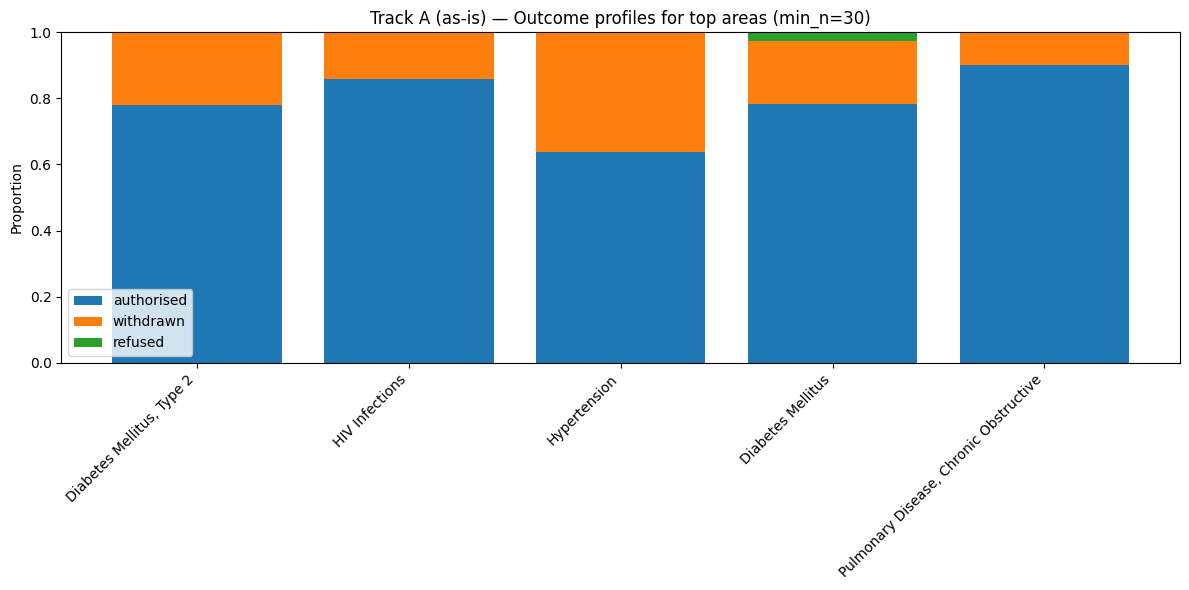

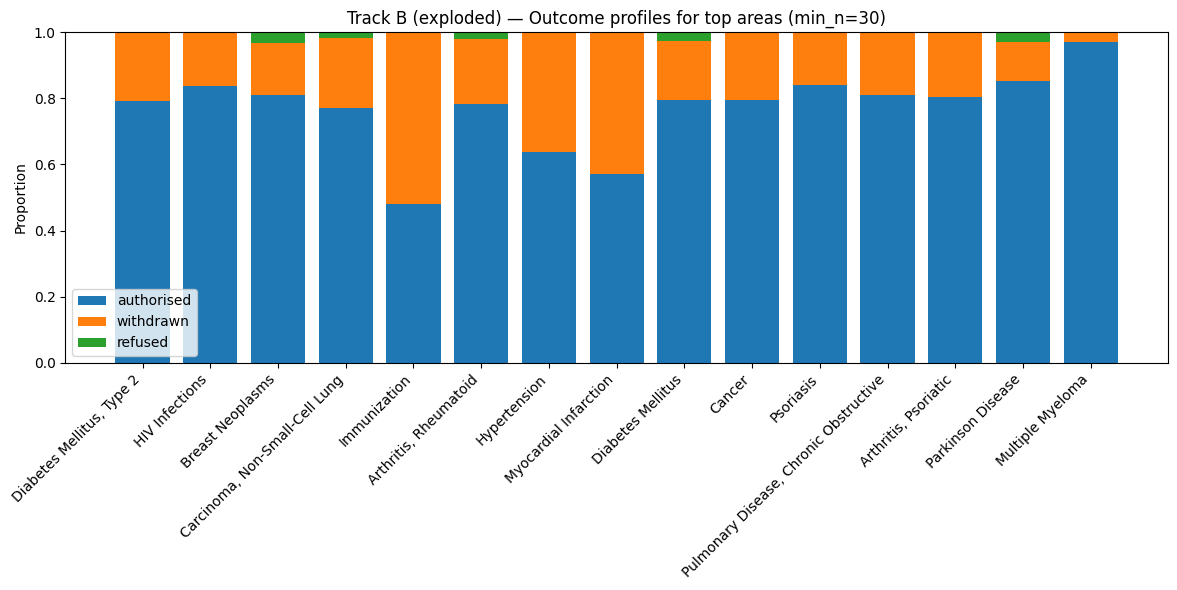

In [17]:
def plot_stacked_profiles(profiles: pd.DataFrame, title: str, top_k: int = 15, save_path: str = None):
    sub = profiles.head(top_k).copy()

    areas = sub.index.tolist()
    p_auth = sub["p_authorised"].values
    p_with = sub["p_withdrawn"].values
    p_ref  = sub["p_refused"].values

    x = np.arange(len(areas))

    plt.figure(figsize=(12, 6))
    plt.bar(x, p_auth, label="authorised")
    plt.bar(x, p_with, bottom=p_auth, label="withdrawn")
    plt.bar(x, p_ref, bottom=p_auth + p_with, label="refused")
    plt.xticks(x, areas, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_stacked_profiles(
    profiles_A,
    title=f"Track A (as-is) — Outcome profiles for top areas (min_n={MIN_N})",
    top_k=min(15, len(profiles_A)),
    save_path=os.path.join(FIG_DIR, f"stacked_profiles_A_min{MIN_N}.png"),
)

plot_stacked_profiles(
    profiles_B,
    title=f"Track B (exploded) — Outcome profiles for top areas (min_n={MIN_N})",
    top_k=min(15, len(profiles_B)),
    save_path=os.path.join(FIG_DIR, f"stacked_profiles_B_min{MIN_N}.png"),
)

## 7. Unsupervised clustering of therapeutic areas

Hierarchical clustering groups therapeutic areas with similar outcome profiles.  
Clusters are used to summarize patterns.

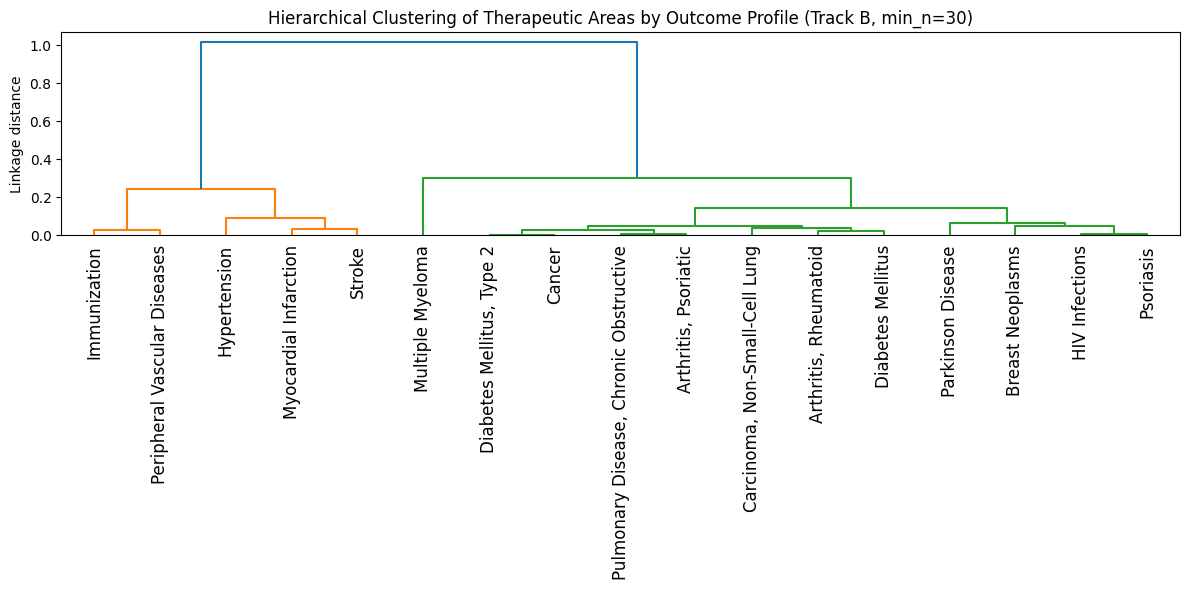

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram

profiles = profiles_B.copy()   # mainline choice
assert profiles.shape[0] >= 10, "Too few high-volume areas — lower MIN_N or revisit preprocessing."

# Feature matrix: outcome proportions per therapeutic area
X = profiles[["p_authorised", "p_withdrawn", "p_refused"]].values
areas = profiles.index.tolist()

# Hierarchical clustering (Ward linkage)
Z = linkage(X, method="ward")

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=areas, leaf_rotation=90)
plt.title(f"Hierarchical Clustering of Therapeutic Areas by Outcome Profile (Track B, min_n={MIN_N})")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dendrogram_B_min{MIN_N}.png"), dpi=200, bbox_inches="tight")
plt.show()

## Summary of learning so far

- High-volume therapeutic areas show meaningful differences in outcome mix (especially authorised vs withdrawn).
- Track B preprocessing (exploding multi-label areas) is necessary to get multiple stable, interpretable high-volume categories.
- Clustering suggests a small number of outcome “regimes,” including a withdrawal-heavy group and a mostly baseline group.

**Limitations (for now):**
- Refusals are rare overall, so most structure is driven by the authorised–withdrawn tradeoff.
- Clustering at this scale should be interpreted qualitatively; a singleton cluster is best treated as an outlier, not a stable regime.
